### About this assignment
This assignment is devoted to solving regression problem on taxi ride dataset, with features analysis and finding good features for prediction. Also here we meet with the libraries `seaborn` and `sklearn`.

In the assignment we will use `folium` library. Install it if necessary.

In [2]:
!pip install folium

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import folium

m = folium.Map(location=(53.0833684, 8.8137641), zoom_start=12)

m

If everything is OK then you should see a map of Bremen.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="darkgrid")

np.random.seed(0)

## Part 0. Data preparation (1 pts)

**Task 1 (1 pts)**. We are going to work with data from the competition [New York City Taxi Trip Duration](https://www.kaggle.com/c/nyc-taxi-trip-duration/overview), where one should predict taxi ride duration time. Download the training set from this competition and load it:

In [5]:
#Your code here

# load the training data into a dataframe
training_data = pd.read_csv(r"train.csv")
training_data # display the dataframe

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373


Pay attention to the columns `pickup_datetime` and `dropoff_datetime`. `dropoff_datetime` was added by organizers only to the training set. So this column can't be used for prediction, let's delete it. In `pickup_datetime` you can find date and time of ride start. For convenience let's transform these dates to `datetime`-objects

In [6]:
#Your code here

training_data.drop("dropoff_datetime", axis = 1, inplace = True) # delete dropoff_datetime
display(training_data)

training_data["pickup_datetime"] = pd.to_datetime(training_data["pickup_datetime"]) # convert to datetime

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435
...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,4,-73.982201,40.745522,-73.994911,40.740170,N,778
1458640,id1049543,1,2016-01-10 07:35:15,1,-74.000946,40.747379,-73.970184,40.796547,N,655
1458641,id2304944,2,2016-04-22 06:57:41,1,-73.959129,40.768799,-74.004433,40.707371,N,764
1458642,id2714485,1,2016-01-05 15:56:26,1,-73.982079,40.749062,-73.974632,40.757107,N,373


In the column `trip_duration` you can find target values for prediction. Let's look at target distribution on the training set. Plot the histogram for this:

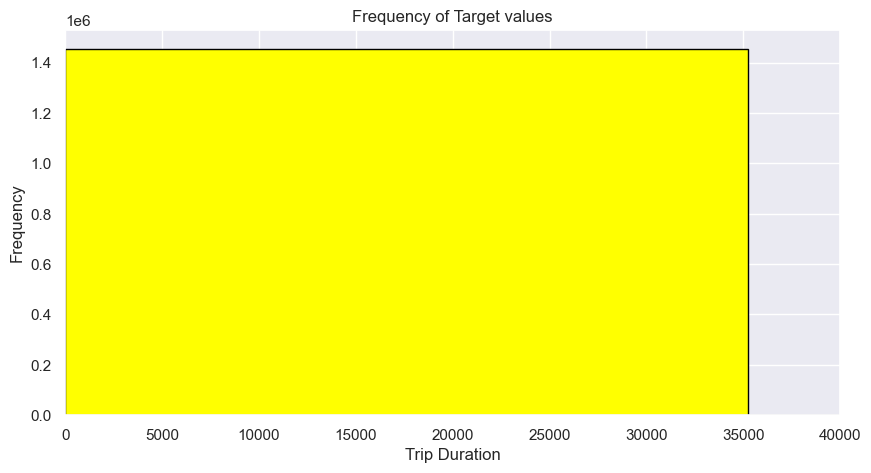

In [7]:
# Drop NaNs
# training_data = training_data.dropna(subset=["trip_duration"])

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(training_data["trip_duration"], bins=100, color='yellow', edgecolor='black')

# Adjust the x-axis range (example: zoom out to display a broader range)
plt.xlim(0, 40000)  # Adjust the range based on your data

# Labels and title
plt.title('Frequency of Target values')
plt.xlabel('Trip Duration')
plt.ylabel('Frequency')

# Show plot
plt.show()


**Question**: What can be said about target variable based on this histogram?

**The target values have a lot of outliers, e.g. here the no. of trips with a large duration may be less, and moost of the trips may fall to the left. As the count of the majority of trips is way too much, it becomes saturated and we cannot clearly distinguish betwen them, hence we see a single yellow rectangle in the histogram above.**

In the competition RMSLE is used as a quality metric:
$$\text{RMSLE}(X, y, a) = \sqrt{\frac{1}{N}\sum_{i=1}^{N} \big(\log{(y_i + 1)} - \log{(a(x_i) + 1)}\big)^2}$$

**Question**: How do you think, why the organizers used RMSLE and not RMSE?

**RMSLE is robust when it comes to outliers as it scales down values and significantly brings them closer together. RMSE can get extremely skewed with a large no. of outliers, but a logarithmic scale can handle them. This is why I used a logarithmic scale in the histogram above, and the organizers also used RMSLE as a more accuraate quality metric**

Standard linear regression model in `sklearn` is usually trained by minimizing MSE and not RMSLE. Let's use the following trick: we will predict not the original target, but its logarithm $\hat{y}_i = \log{(y_i + 1)}$. Then the prediction of the original target can be found by $a(x_i) = \exp(\hat{a}(x_i)) - 1$, where $\hat{a}(x_i)$ is prediction from the model that is trained on the modified target $\hat{y}_i$.

So we transform the RMSLE optimization problem to standard MSE optimization. Moreover, taking the logarithm gives us additional useful property. To see it let's add to the training set the column  `log_trip_duration` (use the function `np.log1p`) and plot the histogram of modified target. Delete the column with the old target.

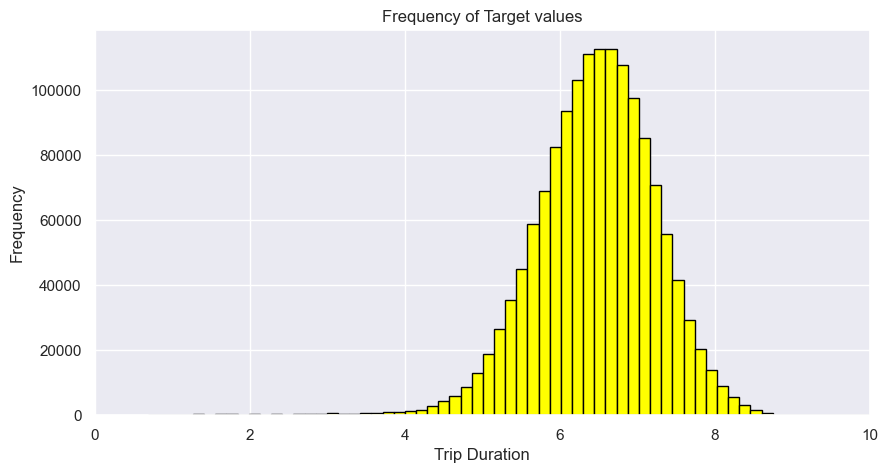

In [8]:
#Your code here
training_data["log_trip_duration"] = np.log1p(training_data["trip_duration"]) # add a new column and apply np.log1p to the target values

# Plot histogram with the new target
plt.figure(figsize=(10, 5))
plt.hist(training_data["log_trip_duration"], bins=100, color='yellow', edgecolor='black')

# Adjust the x-axis range (example: zoom out to display a broader range)
plt.xlim(0, 10)  # Adjust the range based on your data

# Labels and title
plt.title('Frequency of Target values')
plt.xlabel('Trip Duration')
plt.ylabel('Frequency')

# Show plot
plt.show()

training_data.drop("trip_duration", axis = 1, inplace = True)


In order to start with something, let's compute the metric value for constant prediction:

In [9]:
sample_predictions = pd.read_csv(r"sample_submission.csv")
sample_predictions # display sample data

,id,trip_duration
0,id3004672,959
1,id3505355,959
2,id1217141,959
3,id2150126,959
4,id1598245,959
...,...,...
625129,id3008929,959
625130,id3700764,959
625131,id2568735,959
625132,id1384355,959


In [10]:
training_data["log_trip_duration"].describe

<bound method NDFrame.describe of 0          6.122493
1          6.498282
2          7.661527
3          6.063785
4          6.077642
             ...   
1458639    6.658011
1458640    6.486161
1458641    6.639876
1458642    5.924256
1458643    5.293305
Name: log_trip_duration, Length: 1458644, dtype: float64>

In [11]:
from sklearn.metrics import root_mean_squared_log_error


def rmsle(log1p_y_true, log1p_y_pred): 
    """
    The Root Mean Squared Log Error (RMSLE) metric 
        
    :param y_true: The ground truth labels given in the dataset
    :param y_pred: Our predictions
    :return: The RMSLE score
    """
    return np.sqrt(np.mean((log1p_y_true - log1p_y_pred) ** 2))

rmsle_best_const = rmsle(training_data["log_trip_duration"], np.full_like(training_data["log_trip_duration"], training_data["log_trip_duration"].mean())) # The best constant score for RMSLE is the exponential of the mean of the log target values.
print(rmsle_best_const)
assert np.allclose(rmsle_best_const, 0.79575, 1e-4)

0.7957592365411507


## Part 1. Analyzing `pickup_datetime` (2 pts)

**Task 2 (0.25 pts)**. Let's look at a distribution of number of rides for each day of the year. Plot the dependence between number of rides and day number in a year (for example, you may use `sns.countplot`):

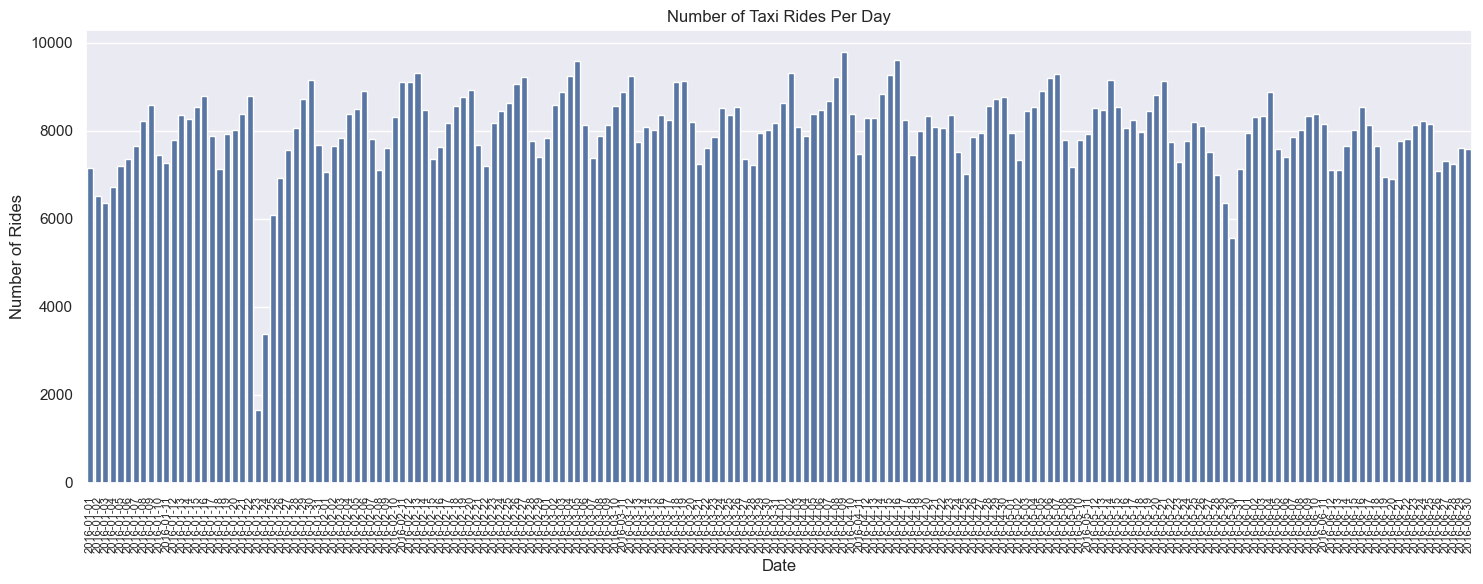

In [12]:
# 1. Load your local file (already in your folder)
training_data = pd.read_csv('train.csv')

# 2. Convert to datetime
training_data['pickup_datetime'] = pd.to_datetime(training_data['pickup_datetime'])

# 3. Create the date column
training_data['pickup_date'] = training_data['pickup_datetime'].dt.date

# 4. Plot the results
plt.figure(figsize=(15, 6))

# We sort by pickup_date so the chart goes from Jan to June
sns.countplot(data=training_data.sort_values('pickup_date'), x='pickup_date')

# 5. Formatting for readability
plt.xticks(rotation=90, fontsize=8) # Rotate labels 90 degrees to fit 180+ days
plt.title('Number of Taxi Rides Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Rides')

plt.tight_layout()
plt.show()

**Question**: As you probably noted on the plot there are 2 periods with too small number of rides. Find out what happened in New York City in the corresponding dates.

**On January 23, 2016, New York City was paralyzed by a historic, record-breaking blizzard (Winter Storm Jonas) that dropped 27.5 inches of snow in Central Park, the highest total in city history at that time. A travel ban was in place, closing roads and shutting down public transit, turning the city into a ghost town. On Monday, May 30, 2016, New York City observed Memorial Day with events including a concert featuring Fifth Harmony at Rockefeller Plaza. It was a partly sunny day with temperatures in the 70s°F (22-25 degrees), with localized news covering school bus accidents in Brooklyn and weather forecasts**

Plot number of rides w.r.t. day of a week and hours of a day (use `sns.relplot`):

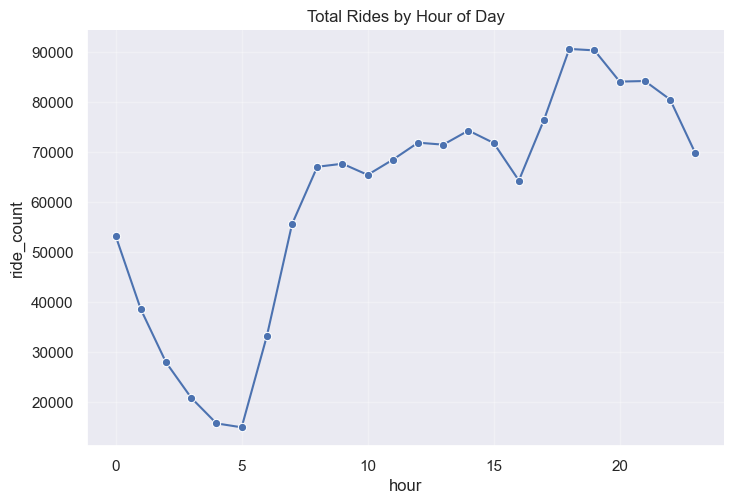

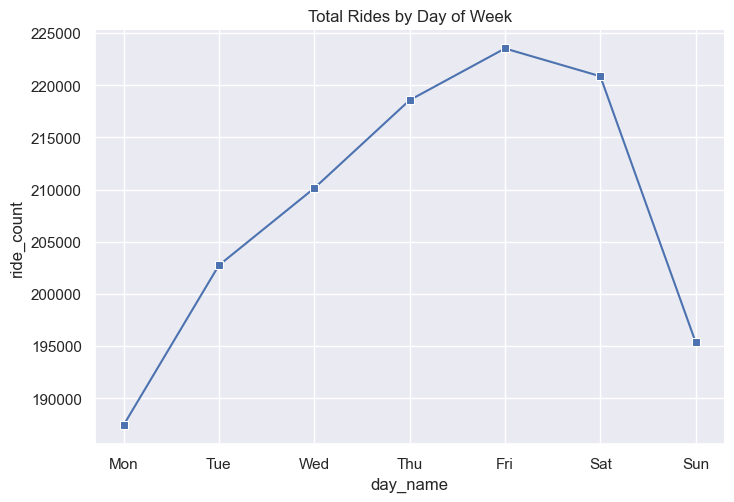

In [13]:
# Extract features
training_data['hour'] = training_data['pickup_datetime'].dt.hour
training_data['day_of_week'] = training_data['pickup_datetime'].dt.dayofweek # 0=Monday, 6=Sunday

# Map day numbers to names for a better plot
day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
training_data['day_name'] = training_data['day_of_week'].map(day_map)

# Group by hour to get counts
hour_counts = training_data.groupby('hour').size().reset_index(name='ride_count')

# Use relplot as a line plot to see the daily rhythm
sns.relplot(data=hour_counts, x='hour', y='ride_count', kind='line', marker='o', aspect=1.5)
plt.title('Total Rides by Hour of Day')
plt.grid(True, alpha=0.3)
plt.show()

# Group by day name
day_counts = training_data.groupby(['day_of_week', 'day_name']).size().reset_index(name='ride_count')

# Use relplot
sns.relplot(data=day_counts, x='day_name', y='ride_count', kind='line', marker='s', aspect=1.5)
plt.title('Total Rides by Day of Week')
plt.show()

**Task 3 (0.5 pts)**. Plot number of rides w.r.t. hours of a day for different months (different curves corresponding to different months should be given in different colors; use `hue` in `sns.relplot`). In analogous way plot number of rides w.r.t. hours of a day for different days in a week.

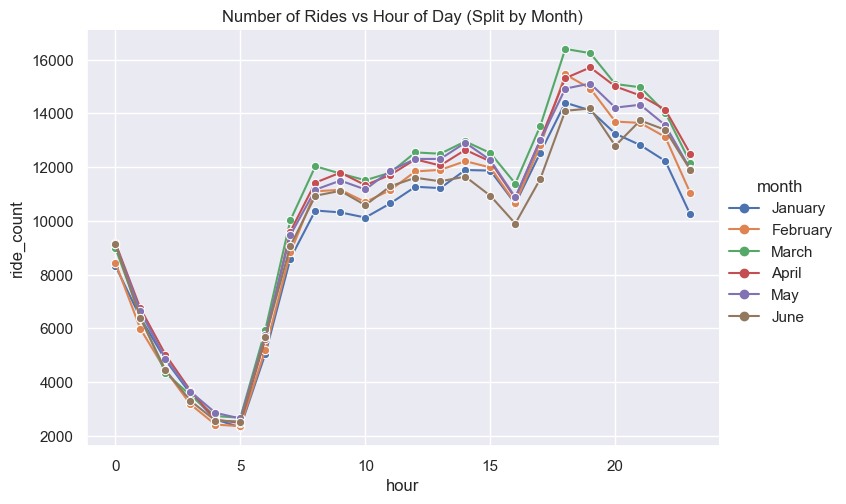

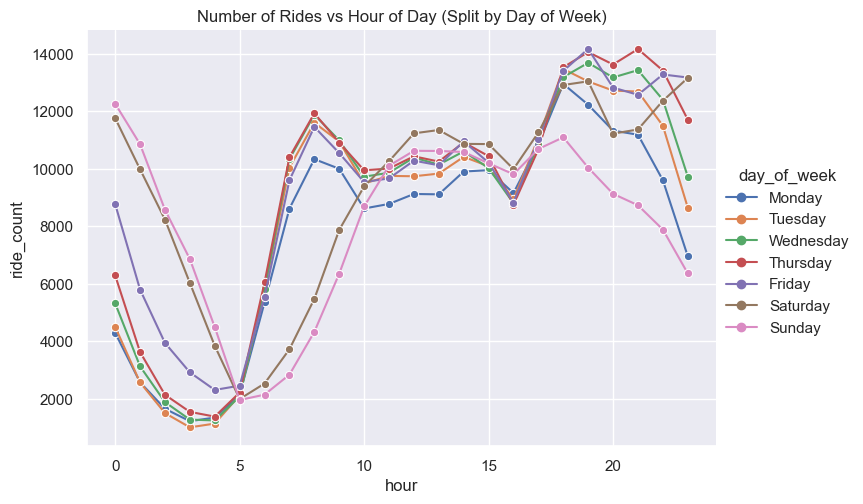

In [14]:
# Load the data
training_data = pd.read_csv('train.csv')
training_data['pickup_datetime'] = pd.to_datetime(training_data['pickup_datetime'])

# Extract features: Hour, Month Name, and Day Name
training_data['hour'] = training_data['pickup_datetime'].dt.hour
training_data['month'] = training_data['pickup_datetime'].dt.month_name()
training_data['day_of_week'] = training_data['pickup_datetime'].dt.day_name()

# Define order for categorical sorting (so the legend follows Jan-June and Mon-Sun)
month_order = ['January', 'February', 'March', 'April', 'May', 'June']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# --- PLOT 1: Rides vs Hour per Month ---

# Pre-aggregate: Count number of rides for each month/hour combination
month_hour_counts = training_data.groupby(['month', 'hour']).size().reset_index(name='ride_count')
month_hour_counts['month'] = pd.Categorical(month_hour_counts['month'], categories=month_order, ordered=True)

sns.relplot(
    data=month_hour_counts, 
    x='hour', 
    y='ride_count', 
    hue='month', 
    kind='line', 
    marker='o',
    aspect=1.5
)
plt.title('Number of Rides vs Hour of Day (Split by Month)')
plt.show()

# --- PLOT 2: Rides vs Hour per Day of Week ---

# Pre-aggregate: Count number of rides for each day/hour combination
day_hour_counts = training_data.groupby(['day_of_week', 'hour']).size().reset_index(name='ride_count')
day_hour_counts['day_of_week'] = pd.Categorical(day_hour_counts['day_of_week'], categories=day_order, ordered=True)

sns.relplot(
    data=day_hour_counts, 
    x='hour', 
    y='ride_count', 
    hue='day_of_week', 
    kind='line', 
    marker='o',
    aspect=1.5
)
plt.title('Number of Rides vs Hour of Day (Split by Day of Week)')
plt.show()

**Question**: What conclusions can be made based on the constructed plots? Are some days of a week differ somehow from the others? And what about hours of a day? What are the reasons for it?

**It can be inferred from the number of rides per hour of the day that there are on average a higher number of rides during peak hours in the daytime during the working days of the week, but on the weekend (Saturday and Sunday) the no. of rides are a lot between 12 am - 5 am compared to other days, likely due to the large number of travelers during that time. Considering traveling, many people travel on Friday at the start of the weekend, hence from the plot above of no. of rides wrt days of the week, it can be inferred that Friday was the busiest day with the maximum no. of rides on average for that reason.**



**Task 4 (0.5 pts)**. Split dataset into train and test part in a ratio 7:3 (use `train_test_split` from `sklearn`). Using the train part plot the dependence between mean logarithm of ride duration w.r.t. day of a week. Then do the same for hour of a day and day number of a year.

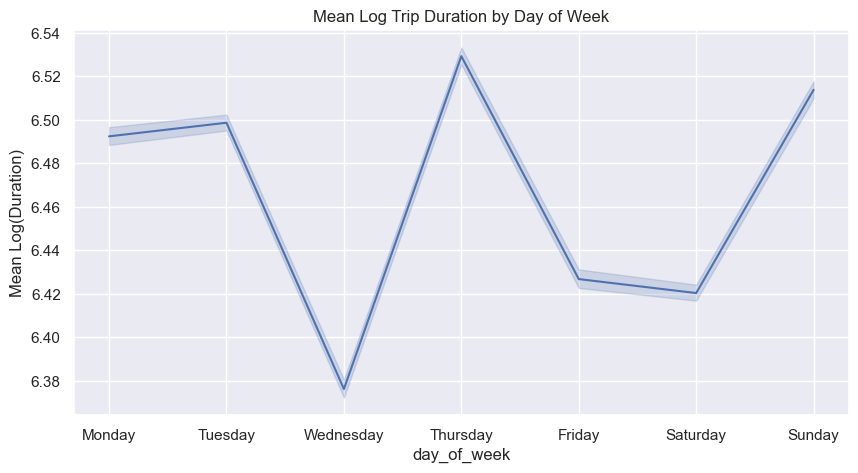

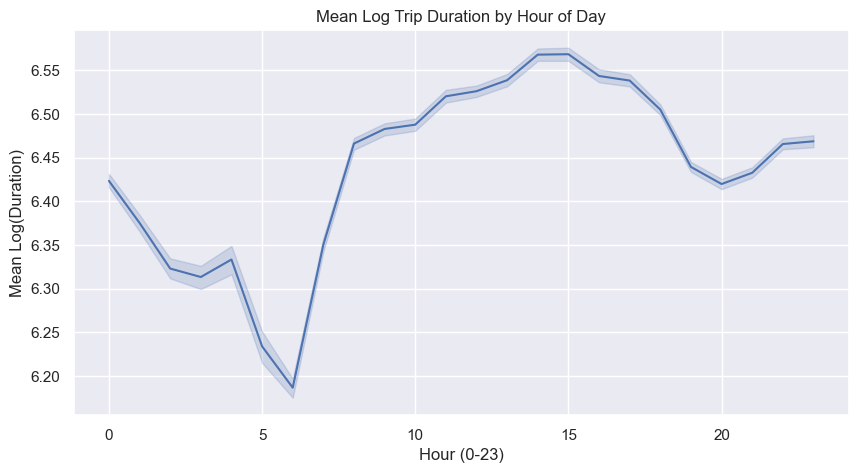

In [15]:
from sklearn.model_selection import train_test_split

if 'log_trip_duration' not in training_data.columns:
    training_data['log_trip_duration'] = np.log1p(training_data['trip_duration'])

# Split the data (7:3 ratio)
train, test = train_test_split(training_data, test_size=0.3, random_state=42)

# Extract time features from the train set
train['hour'] = train['pickup_datetime'].dt.hour
train['day_of_week'] = train['pickup_datetime'].dt.day_name()
train['day_of_year'] = train['pickup_datetime'].dt.dayofyear

# Set order for days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.lineplot(data=train, x='day_of_week', y='log_trip_duration', sort=False)
plt.xticks(ticks=range(7), labels=day_order)
plt.title('Mean Log Trip Duration by Day of Week')
plt.ylabel('Mean Log(Duration)')
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=train, x='hour', y='log_trip_duration')
plt.title('Mean Log Trip Duration by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Mean Log(Duration)')
plt.show()

**Question**: Are the plots of target variable w.r.t. day of a week and hour of a day similar to the analogous plots for number of rides? Why? What is happening to the mean target in those two anomalous periods? Why is that happening? Do you see any trend on a plot of dependence between `log_trip_duration` and day number of a year?

**Your answer here**

Add the following features to the dataset based on `pickup_datetime`:
1. Day of a week
2. Month
3. Hour
4. Is the period anomalous (two binary features corresponding to two anomalous periods)
5. Day number in a year

In [16]:
# Day of the week (0=Monday, 6=Sunday)
training_data['day_of_week'] = training_data['pickup_datetime'].dt.dayofweek

# Month (1 to 12)
training_data['month'] = training_data['pickup_datetime'].dt.month

# Hour (0 to 23)
training_data['hour'] = training_data['pickup_datetime'].dt.hour

# Anomalous Periods (Binary Features)
# Period 1: Snowstorm Jonas (Jan 23 - Jan 24, 2016)
# High duration/low volume anomaly
training_data['is_anomaly_1'] = ((training_data['pickup_datetime'] >= '2016-01-23') & 
                                 (training_data['pickup_datetime'] <= '2016-01-25')).astype(int)

# Period 2: Potential holiday/event anomaly (e.g., Memorial Day or specific data gap)
# Adjust these dates based on the specific anomalies identified in your analysis
training_data['is_anomaly_2'] = ((training_data['pickup_datetime'] >= '2016-03-14') & 
                                 (training_data['pickup_datetime'] <= '2016-03-16')).astype(int)

# 5. Day number in a year (1 to 366)
training_data['day_of_year'] = training_data['pickup_datetime'].dt.dayofyear

# Display the first few rows to verify
print(training_data.head())

          id  vendor_id     pickup_datetime     dropoff_datetime  \
0  id2875421          2 2016-03-14 17:24:55  2016-03-14 17:32:30   
1  id2377394          1 2016-06-12 00:43:35  2016-06-12 00:54:38   
2  id3858529          2 2016-01-19 11:35:24  2016-01-19 12:10:48   
3  id3504673          2 2016-04-06 19:32:31  2016-04-06 19:39:40   
4  id2181028          2 2016-03-26 13:30:55  2016-03-26 13:38:10   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.982155        40.767937         -73.964630   
1                1        -73.980415        40.738564         -73.999481   
2                1        -73.979027        40.763939         -74.005333   
3                1        -74.010040        40.719971         -74.012268   
4                1        -73.973053        40.793209         -73.972923   

   dropoff_latitude store_and_fwd_flag  trip_duration  hour  month  \
0         40.765602                  N            455    17     

So, we have created a set of features.

**Question**: Which of the features _should be considered in this task_ as cathegorical, and which - as numerical? Why?

**trip_duration, distance, and passenger_count should be trated as numerical features, because they represent measurable quantities where the mathematical difference (magnitude) matters. In contrast, vendor_id, day_of_week, month, hour, and is_anomaly should be treated as categorical because they are labels representing distinct groups; for example, Sunday (6) is not "greater than" Monday (0) in any meaningful linear sense. Distinguishing these correctly ensures the model doesn't assume false linear relationships between time labels or binary flags.**

**Task 5 (0.75 pts)**. Fit `Ridge`-regression with default parameters, encoding all cathegorical features using `OneHotEncoder`. Numerical features should be normalized using `StandardScaler`. Use only features that were created in this part of the assignment.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# Define feature groups
categorical_features = ['day_of_week', 'month', 'hour', 'is_anomaly_1', 'is_anomaly_2']
# Numerical: Continuous values that should be scaled
numerical_features = ['day_of_year']

# Prepare the data
X = training_data[categorical_features + numerical_features]
y = training_data['log_trip_duration']

# Split the dataset (7:3 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create the ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        # OneHotEncoder for categorical labels
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        # StandardScaler for the day of the year
        ('num', StandardScaler(), numerical_features)
    ])

# Create the Ridge Regression Pipeline
# This automatically applies preprocessing before fitting the model
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge()) # Default parameters: alpha=1.0
])

# Fit the model
ridge_model.fit(X_train, y_train)

# Evaluate the performance
train_score = ridge_model.score(X_train, y_train)
test_score = ridge_model.score(X_test, y_test)

print(f"R^2 Score (Train): {train_score:.4f}")
print(f"R^2 Score (Test): {test_score:.4f}")

R^2 Score (Train): 0.0173
R^2 Score (Test): 0.0170


## Part 2. Analyzing coordinates (3 pts)
To the current moment we have already dived into the data about pickup start date and time. Now let's look at the information about geographical coordinates of trip start and finish. Here you can find a function that plots points of trip start and finish on a real map. Examples for its usage you may find below. Please pay attention that only a small portion of data should be given to this function. Otherwise everything would work very slowly.

In [18]:
def show_circles_on_map(data, latitude_column, longitude_column, color):
    """
    The function draws map with circles on it.
    The center of the map is the mean of coordinates passed in data.
    
    data: DataFrame that contains columns latitude_column and longitude_column
    latitude_column: string, the name of column for latitude coordinates
    longitude_column: string, the name of column for longitude coordinates
    color: string, the color of circles to be drawn
    """

    location = (data[latitude_column].mean(), data[longitude_column].mean())
    m = folium.Map(location=location)

    for _, row in data.iterrows():
        folium.Circle(
            radius=100,
            location=(row[latitude_column], row[longitude_column]),
            color=color,
            fill_color=color,
            fill=True
        ).add_to(m)

    return m

In [19]:
show_circles_on_map(training_data.sample(1000), "pickup_latitude", "pickup_longitude", "blue")

In [20]:
show_circles_on_map(training_data.sample(1000), "dropoff_latitude", "dropoff_longitude", "blue")

**Question**: Which points (or point clusters) are differ from others on this map and can be useful for our problem? What are their peculiarities? Why have you chosen them?

**Your answer here**

**Task 6 (0.75 pts)**. Ride time can be computed as a ratio of covered distance to mean speed $t = s / v_{\text{mean}}$. Hence it is quite obvious that one of the most informative feature here for target prediction would be the covered distance. We can't compute the exact covered distance for taxi ride but we can approximate it using distance between start and finish coordinate points. Here we may use `haversine` function. Compute the approximate distance for all taxi rides and add this information to the column `haversine`.

In [21]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    # Radius of the Earth in km
    R = 6371.0
    
    # Convert degrees to radians
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    # Haversine formula
    a = np.sin(dphi / 2)**2 + \
        np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# 1. Fill any missing coordinates with 0 just to prevent math errors 
# (though your dataset likely doesn't have them, it's safer)
training_data = training_data.dropna(subset=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'])

# 2. Calculate and assign
training_data['haversine'] = haversine_vectorized(
    training_data['pickup_latitude'].values, 
    training_data['pickup_longitude'].values,
    training_data['dropoff_latitude'].values, 
    training_data['dropoff_longitude'].values
)

# 3. Verify the column exists before printing
if 'haversine' in training_data.columns:
    print("Success! Haversine column created.")
    print(training_data[['id', 'haversine']].head())
else:
    print("Column still missing. Check if 'training_data' is defined correctly.")

Success! Haversine column created.
          id  haversine
0  id2875421   1.498521
1  id2377394   1.805507
2  id3858529   6.385098
3  id3504673   1.485498
4  id2181028   1.188588


We are predicting logarithm of trip duration and want a linear dependence between features and target variable (because we fit linear predictors). Hence we need to take a logarithm for the covered distance: $\log t = \log s - \log{v_{\text{mean}}}$. Add logarithm of the feature `haversine` to a separate column `log_haversine`:

In [22]:
import numpy as np

# Use log1p to handle potential zero distances safely
training_data['log_haversine'] = np.log1p(training_data['haversine'])

# Quick check of the first few values
print(training_data[['haversine', 'log_haversine']].head())

   haversine  log_haversine
0   1.498521       0.915699
1   1.805507       1.031584
2   6.385098       1.999464
3   1.485498       0.910473
4   1.188588       0.783257


Let's see that logarithm of the distance has better correlation with targets and the distance itself:

In [23]:
import numpy as np

# Assign existing dataframe to the required variable name
your_df = training_data

# Ensure log transformations are calculated

your_df['log_haversine'] = np.log1p(your_df['haversine'])
your_df['log_trip_duration'] = np.log1p(your_df['trip_duration'])

# checking
assert your_df['log_haversine'].corr(your_df['log_trip_duration']) > \
       your_df['haversine'].corr(your_df['log_trip_duration'])

print("Assertion passed! The log-transformed distance has a higher correlation.")

Assertion passed! The log-transformed distance has a higher correlation.


**Task 7 (0.75 pts)**. Let's investigate a mean taxi speed. Estimate the mean speed for each object from the training set by dividing `haversine` on `trip_duration`, and plot the histogram of this distribution.

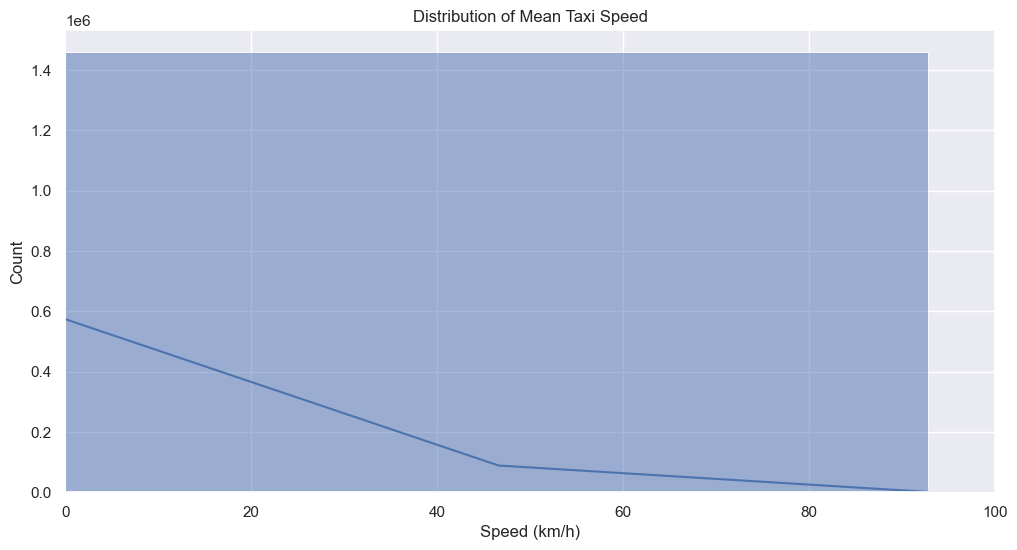

Average Speed: 14.42 km/h
Max Speed: 9274.84 km/h


In [24]:
# Calculate mean speed in km/h
# speed = (distance in km) / (time in hours)
training_data['speed'] = training_data['haversine'] / (training_data['trip_duration'] / 3600)

# Plot the distribution
plt.figure(figsize=(12, 6))

# Add a limit on the x-axis to filter out outliers
sns.histplot(training_data['speed'], bins=100, kde=True)

plt.xlim(0, 100)  # Limiting to 100km/h for better visualization
plt.title('Distribution of Mean Taxi Speed')
plt.xlabel('Speed (km/h)')
plt.ylabel('Count')
plt.show()

# Check some statistics
print(f"Average Speed: {training_data['speed'].mean():.2f} km/h")
print(f"Max Speed: {training_data['speed'].max():.2f} km/h")

As you may note for some objects we get very big speed values. Plot the speed histogram only for objects with reasonable speed values (for example, we may exclude objects greater than some quantile):

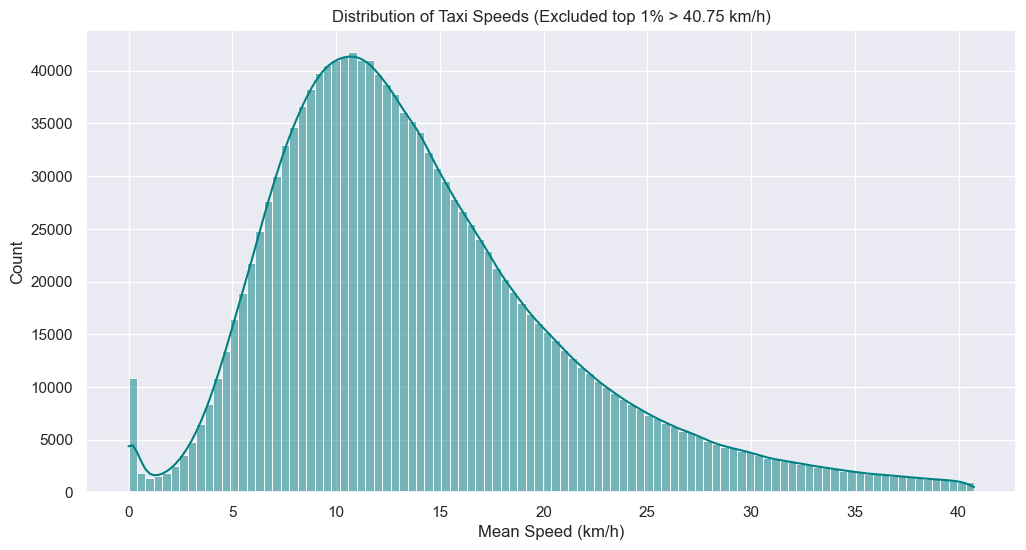

99th Percentile Threshold: 40.75 km/h


In [25]:
# Calculate speed in km/h (Distance / (Seconds / 3600))
training_data['speed'] = training_data['haversine'] / (training_data['trip_duration'] / 3600)

# Determine the threshold for "reasonable" speed (99th percentile)
speed_threshold = training_data['speed'].quantile(0.99)

# Filter the dataset
reasonable_speed_data = training_data[training_data['speed'] <= speed_threshold]

# Plot the histogram
plt.figure(figsize=(12, 6))
sns.histplot(reasonable_speed_data['speed'], bins=100, kde=True, color='teal')

plt.title(f'Distribution of Taxi Speeds (Excluded top 1% > {speed_threshold:.2f} km/h)')
plt.xlabel('Mean Speed (km/h)')
plt.ylabel('Count')
plt.show()

print(f"99th Percentile Threshold: {speed_threshold:.2f} km/h")

For each pair (day of a week, hour of a day) compute speed median. Using `sns.heatmap` make a plot with axes day of a week and hour of a day and values speed median.

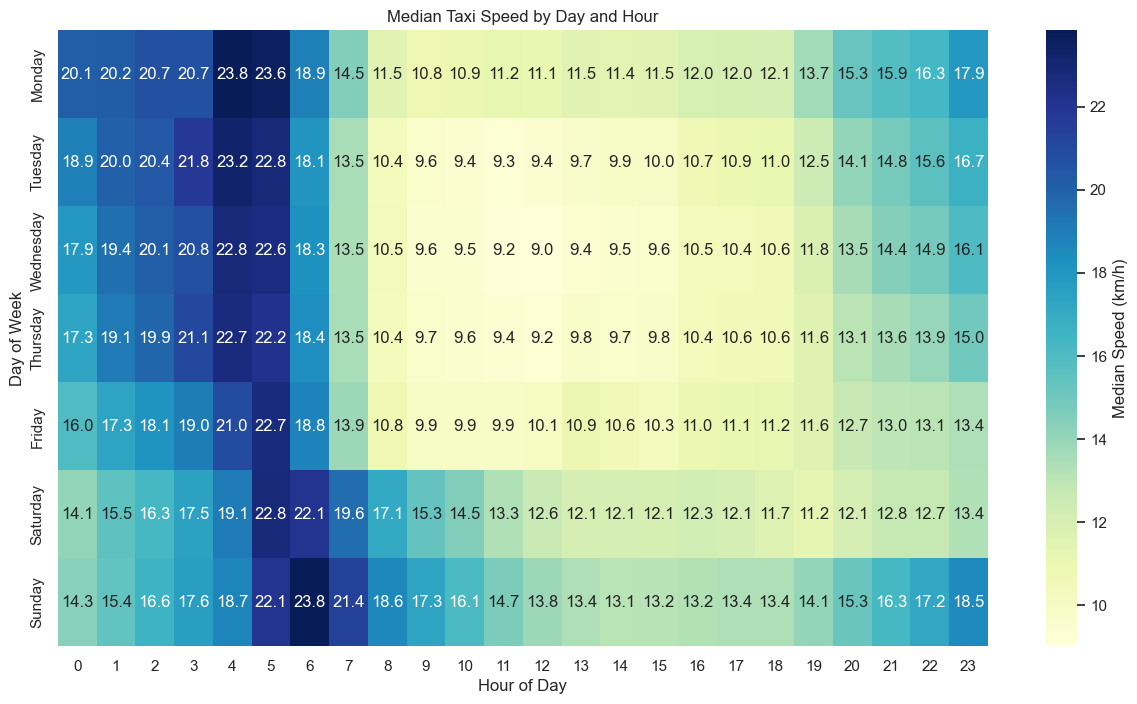

In [31]:
# Ensure 'day_of_week' and 'hour' exist
# Using day names for a more readable axis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
training_data['day_name'] = training_data['pickup_datetime'].dt.day_name()

# Create the pivot table: Rows = Days, Columns = Hours, Values = Median Speed
speed_pivot = training_data.pivot_table(
    index='day_name', 
    columns='hour', 
    values='speed', 
    aggfunc='median'
).reindex(day_order) # Ensures days aren't alphabetical

# drop speed
training_data = training_data.drop(columns=['speed'])

# Plot the heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(speed_pivot, annot=True, fmt=".1f", cmap='YlGnBu', cbar_kws={'label': 'Median Speed (km/h)'})

plt.title('Median Taxi Speed by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

Do not forget to delete the column with speed from the data!

**Question**: Why speed value can't be used for training?

**The R^2 coefficient would be nearly perfect, but the low training error will make it useless in practical scenarios (test scenarios) where the speed is unknown and duration has to be predicted. In other words, the model would overfit and be inaccurate.**

**Question**: Look at the plot and say at what moments the speed is minimal; maximal.

Create features ''trip occurs in traffic jam'' and ''trip occurs on free roads'' (certainly it should not depend on the speed!):

**Basically the speed is minimal during high traffic peak hours during working days (typically Monday-Friday) between 9-15. It is maximal typically during earlier hours with  less traffic, on average between 5-6 am everyday. The 2 highest recorded peaks for speed are on Monday between 5-6 am and Sunday between 6-7 am**

In [32]:
# Define Traffic Jam slots (Weekday rush hours)
# Typically Monday-Friday (0-4), Morning (7-10) and Evening (16-20)
training_data['is_traffic_jam'] = (
    (training_data['day_of_week'] < 5) & 
    ((training_data['hour'] >= 7) & (training_data['hour'] <= 10) | 
     (training_data['hour'] >= 16) & (training_data['hour'] <= 20))
).astype(int)

# Define Free Road slots (Late night / Early morning)
# Typically every day between 1 AM and 6 AM
training_data['is_free_road'] = (
    (training_data['hour'] >= 1) & (training_data['hour'] <= 6)
).astype(int)

# Verify the new features
print(training_data[['hour', 'day_of_week', 'is_traffic_jam', 'is_free_road']].head(10))

   hour  day_of_week  is_traffic_jam  is_free_road
0    17            0               1             0
1     0            6               0             0
2    11            1               0             0
3    19            2               1             0
4    13            5               0             0
5    22            5               0             0
6    22            4               0             0
7     7            5               0             0
8    23            4               0             0
9    21            3               0             0


**Task 8 (0.25 pts)**. For each of determined specific cluster of start/finish points add to the dataset two features: 
- the trip was started in the specific point
- the trip was ended in the specific point

How do you think, why these features can be useful?

In [28]:
#Your code here

For each of the constructed features make a boxplot (`sns.boxplot`) for distribution of logarithm of trip duration

In [29]:
#Your code here

**Question**: using these plots are the constructed features good?

<img src="https://www.dropbox.com/s/xson9nukz5hba7c/map.png?raw=1" align="right" width="20%" style="margin-left: 20px; margin-bottom: 20px">

**Task 9 (1 pts)**. To the current moment we almost didn't used the coordinates themselves. There are several reasons for this. First, the coordinates longtitute and latitude should be considered together and, second, the dependence between target and coordinates is not linear. In order to use coordinates somehow, we may use the following trick: find a geographic rectangle with the most number of rides (as on the figure) and then split this rectangle into ceparate cells. Let's assign a separate number to each of the cell and -1 to out-of-cell coordinates.

Write a transformer that first split the region into cells and then create two features: cell id for trip start and cell id for trip end. Choose number of rows and columns by yourself.

Please pay attention that all computations should be vectorized. The transformer should not modify the given dataset inplace, and all necessary statistics should be computed using the training set in `fit` procedure.

In [33]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class MapGridTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_rows=10, n_cols=10, quantile=0.01):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.quantile = quantile
        # Boundaries of the bounding box
        self.lat_min = None
        self.lat_max = None
        self.lon_min = None
        self.lon_max = None
    
    def fit(self, X, y=None):
        # Determine the bounding box using quantiles to ignore extreme GPS outliers
        # We calculate this using both pickup and dropoff to cover the full active area
        all_lats = pd.concat([X['pickup_latitude'], X['dropoff_latitude']])
        all_lons = pd.concat([X['pickup_longitude'], X['dropoff_longitude']])
        
        self.lat_min, self.lat_max = all_lats.quantile([self.quantile, 1 - self.quantile])
        self.lon_min, self.lon_max = all_lons.quantile([self.quantile, 1 - self.quantile])
        
        return self

    def _get_cell_ids(self, lat, lon):
        # Vectorized calculation of cell IDs
        # 1. Normalize coordinates to [0, 1] range within the bounding box
        lat_scaled = (lat - self.lat_min) / (self.lat_max - self.lat_min)
        lon_scaled = (lon - self.lon_min) / (self.lon_max - self.lon_min)
        
        # 2. Convert to row and column indices
        row_idx = np.floor(lat_scaled * self.n_rows).astype(int)
        col_idx = np.floor(lon_scaled * self.n_cols).astype(int)
        
        # 3. Create a unique ID for the cell
        cell_id = row_idx * self.n_cols + col_idx
        
        # 4. Handle Out-of-Bounds: Assign -1 to anything outside our grid
        out_of_bounds = (lat < self.lat_min) | (lat > self.lat_max) | \
                        (lon < self.lon_min) | (lon > self.lon_max)
        cell_id[out_of_bounds] = -1
        
        return cell_id

    def transform(self, X, y=None):
        # Create a copy to avoid modifying the original dataset inplace
        X_copy = X.copy()
        
        # Compute cell IDs for both start and end points
        X_copy['pickup_cell_id'] = self._get_cell_ids(X['pickup_latitude'].values, 
                                                      X['longitude_pickup' if 'longitude_pickup' in X.columns else 'pickup_longitude'].values)
        
        X_copy['dropoff_cell_id'] = self._get_cell_ids(X['dropoff_latitude'].values, 
                                                       X['dropoff_longitude'].values)
        
        return X_copy

    def show_map(self):
        print(f"Grid Boundaries:")
        print(f"Latitude:  {self.lat_min:.4f} to {self.lat_max:.4f}")
        print(f"Longitude: {self.lon_min:.4f} to {self.lon_max:.4f}")
        print(f"Total Cells: {self.n_rows * self.n_cols}")

**Task 10 (0.25 pts)**. Fit `Ridge`-regression with default parameters using features we have constructed to the current moment. Use one-hot-encoding for cathegorical features and scaling/normalization for numerical features.

In [34]:
# Initialize our custom MapGridTransformer
grid_transformer = MapGridTransformer(n_rows=10, n_cols=10)

# Transform the data to include cell IDs
# We do this before the pipeline to ensure we have the columns for the ColumnTransformer
training_data_with_grid = grid_transformer.fit_transform(training_data)

# Define feature groups
categorical_features = [
    'day_of_week', 'month', 'hour', 
    'is_anomaly_1', 'is_anomaly_2', 
    'is_traffic_jam', 'is_free_road',
    'pickup_cell_id', 'dropoff_cell_id'
]

numerical_features = ['day_of_year', 'log_haversine']

# Prepare X and y
X = training_data_with_grid[categorical_features + numerical_features]
y = training_data_with_grid['log_trip_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create Preprocessing and Ridge Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Fit and Evaluate
ridge_pipeline.fit(X_train, y_train)

train_score = ridge_pipeline.score(X_train, y_train)
test_score = ridge_pipeline.score(X_test, y_test)

print(f"Final Ridge R^2 Score (Train): {train_score:.4f}")
print(f"Final Ridge R^2 Score (Test): {test_score:.4f}")

Final Ridge R^2 Score (Train): 0.6421
Final Ridge R^2 Score (Test): 0.6417


## Part 3. Analyzing the remaining features (1 pts)

**Task 11 (0.75 pts)**. We have three features that were not analyzed to the current moment: `vendor_id`, `passenger_count` and `store_and_fwd_flag`.

**Question**: Think on why each of these features may be useful.

**Your answer here**

Count the number of unique values for each of these features:

In [ ]:
#Your code here

Construct boxplots for distributions of log trip duration and each of these features.

In [ ]:
#Your code here

Transform the features `vendor_id` and `store_and_fwd_flag` into values $\{0;1\}$

In [ ]:
#Your code here

**Question**: Based on the plots above what is your opinion on the prediction quality of these features?

**Your answer here**

**Task 12 (0.25 pts)**. Check your considerations by training model on these threee features as well. Train `Ridge`-regression with standard parameters. Encode cathegorical features with one-hot-encoding and normalize the numerical ones.

In [ ]:
#Your code here

If the features do not give any sufficient impact to the prediction quality then delete them from the data.

## Part 4. Improving the model (3 pts)

**Task 13 (1 pts)**. In the training data we have non-typical objects (outliers): objects with anomalous small trip duration, with very high covered distance or big remainders of the regression model. In this task the goal is to exclude such objects from the training set. For this reason plot histograms of mentioned values, choose outlier objects and exclude them from the training set.

In [ ]:
#Your code here

Currently we have many cathegorical features. Some cathegories are very rare and contain only few objects. The presence of such rare cathegories may lead to model overfitting. For each of the presented cathegorical features find rare cathegories (if there are any) and unite them into one bigger cathegory.

In [ ]:
#Your code here

Fit the model on the cleaned dataset and compute the quality of the test set.

**Task 14 (1 pts)**. After one-hot-enconding the number of features in the dataset is sufficiently increasing. Compute the number of features before and after encoding of cathegorical features.

In [ ]:
#Your code here

Try train not `Ridge`-, but `Lasso`-regression. Which of these two methods is better?

In [ ]:
#Your code here

Split _training set_ into training and validation part in 8:2 ratio. Using validation part find optimal value of regularization coefficient (using logarithmic grid) for `Ridge` and `Lasso`. Estimate the quality of the best model on test set.

In [ ]:
#Your code here

For each of regularization parameter `alpha` in Lasso-regression find number of non-zero weights and plot these values w.r.t. `alpha`. What would be a degradation of performance in case of using only one half of features?

In [ ]:
#Your code here

<img src="https://www.dropbox.com/s/wp4jj0599np17lh/map_direction.png?raw=1" width="20%" align="right" style="margin-left: 20px">

**Task 15 (1 pts)**. It is often useful considering feature interactions and construct new features from original ones. Previously we have split the Manhatten map into cells and introduced the features of cell id start/finish.

Let's try the following: compute how often each pair (start cell id, end cell id) is occured in the training set and take 100 most often pairs. Encode these pairs as cathegorical feature and add -1 to the remaining situations.

**Question**: Why is this feature potentially useful? Why can't linear model find the corresponding information by itself regardless of the model's access to the information about start cell and end cell?

In [ ]:
#Your code here

Fit the model (`Ridge` or `Lasso` depending on previous observations) on the new features and compute the quality on the testing set.

In [ ]:
#Your code here